In [ ]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
from tqdm import tqdm
from data_loader import *

# Collect Stats and Do SVD

In [2]:
A_train, A_test, Ind_train, Ind_test = load_movielen_100k_split('ml-100k')
#A_train, A_test, Ind_train, Ind_test = load_movielen_1m_split('ml-1m')
#A_train, A_test, Ind_train, Ind_test = load_movielen_10m_split('ml-10m')
A = A_train

Loading done!                       .

In [3]:
m,n = A.shape

assert(isinstance(A, np.ndarray) or isinstance(A, sp.csr_matrix))
sparse = not isinstance(A, np.ndarray)

maxk = min(m,n)
assert(m*n <= 1<<24 or sparse)
if m*n > 1<<24 or sparse:
    maxk = min(200, min(m,n)-1) # sp.svds requres 0 < k < min(m,n) (not <= min(m,n))

print(f'----- Metadata of A -----')
print('A is stored as '+('sparse matrix(sp.csr_matrix).' if sparse else 'dense matrix(np.ndarray).'))
print(f'm = {m}, n = {n}')
print(f'k is taken from 1 to {maxk}')

print('Doing SVD...')
if sparse:
    U,  S,  Vh  = sp.linalg.svds(A, k=200, tol=0.1)
    # scipy.sparse.linalg.svds returns singular values in ascending order
    S = S[::-1]
    U = U[:,::-1]
    Vh= Vh[::-1,:]
else:
    U,  S,  Vh  = np.linalg.svd(A)
V = Vh.T.conj()

----- Metadata of A -----
A is stored as sparse matrix(sp.csr_matrix).
m = 943, n = 1682
k is taken from 1 to 200
Doing SVD...


# Compute model TPR for different $k$

In [9]:
def sample_j_from_Ind_test(Ak, Ind_test, i, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    candidates = np.array(Ind_test[i], dtype=int)
    if len(candidates) == 0:
        return None

    vals = Ak[i, candidates]
    if sp.issparse(vals):
        vals = vals.toarray().ravel()
    else:
        vals = np.asarray(vals).ravel()

    weights = vals.astype(float) ** 2
    total = weights.sum()

    if total <= 0:
        return None

    probs = weights / total
    return rng.choice(candidates, p=probs)

def test_model_accuracy(maxk, nr_sample=10000, progress_bar=True, rng=None):
    Ak = np.zeros((m,n))
    for k in tqdm(range(maxk), disable=not progress_bar):
        Ak += S [k] * U [:, k:k+1] @ Vh [k:k+1, :]

    weights_i = np.array([len(Ind_train[i]) for i in range(m)], dtype=float)
    prob_i = weights_i / weights_i.sum()

    correct = 0
    for t in tqdm(range(nr_sample), disable=not progress_bar):
        i = rng.choice(m, p=prob_i)
        j = sample_j_from_Ind_test(Ak, Ind_test, i, rng=rng)

        if j is None:
            continue

        correct += A_test[i, j] == 1

    return correct / nr_sample

k_cutoff = [1,2,3,5,8,10,12,15,20,25,30,35,40,50,60]
accuracy = []
for k in tqdm(k_cutoff):
    accuracy.append(test_model_accuracy(k, nr_sample=10000, progress_bar=False, rng=np.random.default_rng(seed=3174)))

100%|██████████| 15/15 [00:18<00:00,  1.25s/it]


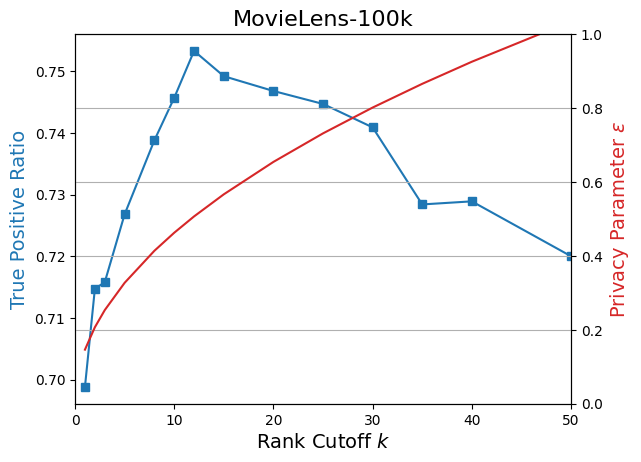

In [11]:
def eps_delta(μ, m, n, k, ε_approx, Trowmin, C_eps=2, C_delta=2):
    eps = C_eps * np.sqrt(μ*k / n)

    fac1 = 1/min(m,n)
    fac2 = 1/np.sqrt(m*n)
    delta_nom = (μ*k)**2 * ((fac1 + fac2)**2 - fac1**2)
    delta_den = Trowmin*ε_approx
    delta = delta_nom/delta_den
    delta = C_delta * delta

    return eps, delta

X = k_cutoff
Y = accuracy
Eps = [eps_delta(9, A.shape[0], A.shape[1], k, (np.cumsum(S**2)/sp.linalg.norm(A, ord='fro')**2)[k], 20, 2, 2)[0] for k in X]

fig, ax1 = plt.subplots()

# left y axis
ax1.plot(X, accuracy, color='C0', marker='s')
ax1.set_xlabel('Rank Cutoff $k$', fontsize=14)
ax1.set_ylabel('True Positive Ratio', color='C0', fontsize=14)
ax1.tick_params(axis='y')

# right y axis
ax2 = ax1.twinx()
ax2.plot(X, Eps, color='C3',)
ax2.set_ylabel('Privacy Parameter $\\varepsilon$', color='C3', fontsize=14)
ax2.tick_params(axis='y')
ax2.set_ylim(bottom=0, top=1)

plt.xlim(0,50)

plt.grid()
plt.title('MovieLens-100k', fontsize=16)
plt.savefig('figures/tpr_eps_tradeoff_MovieLens-100k.pdf', dpi=400, bbox_inches='tight')